# Task 2: Storytelling Dashboard

This dashboard tells the story of who survived the Titanic and how class, sex, age, and fare were connected to that outcome.
The main idea is to compare passenger groups side by side so the patterns are easy to see in one figure.
Each panel supports the same theme: survival was not random, and travel conditions helped shape the result.

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

# Show plots inside the notebook.
%matplotlib inline

In [2]:
# Load the Titanic dataset.
df = pd.read_csv(r"c:\Users\PM\Desktop\Internship\AI-Data-Engineering-Internship\Week-6 May_26\Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Make a copy so the original data stays unchanged.
plot_df = df.copy()

# Convert the columns we need for the dashboard into numeric values.
plot_df["Age"] = pd.to_numeric(plot_df["Age"], errors="coerce")
plot_df["Fare"] = pd.to_numeric(plot_df["Fare"], errors="coerce")
plot_df["SurvivedLabel"] = plot_df["Survived"].map({0: "Did not survive", 1: "Survived"})

plot_df[["Age", "Fare", "SurvivedLabel"]].head()

,Age,Fare,SurvivedLabel
0,22.0,7.2500,Did not survive
1,38.0,71.2833,Survived
2,26.0,7.9250,Survived
3,35.0,53.1000,Survived
4,35.0,8.0500,Did not survive


In [4]:
# Set a consistent visual style and color palette.
sns.set_theme(style="whitegrid")
survival_palette = {"Did not survive": "#D95F02", "Survived": "#1B9E77"}
class_palette = {1: "#4C78A8", 2: "#F58518", 3: "#54A24B"}
survival_palette

{'Did not survive': '#D95F02', 'Survived': '#1B9E77'}

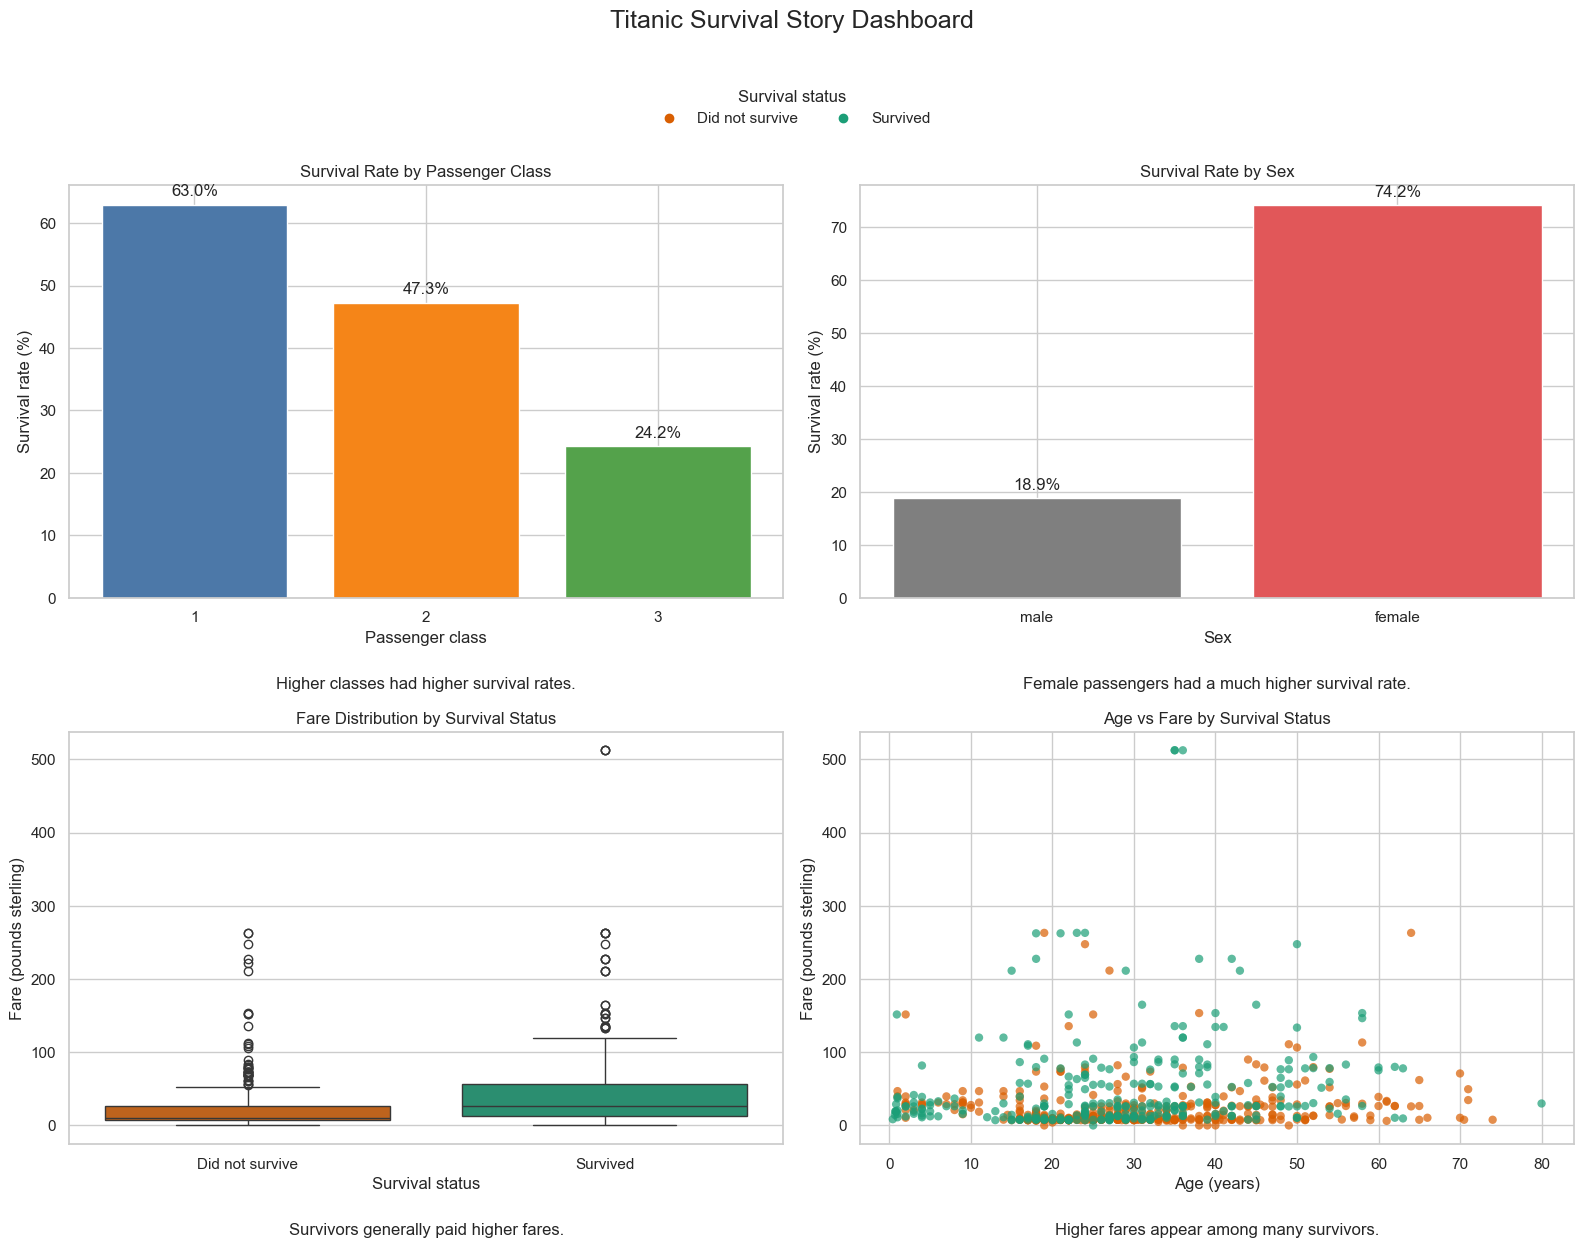

In [6]:
# Dashboard cell: build the 2x2 subplot figure.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: survival by passenger class.
class_order = [1, 2, 3]
class_survival = plot_df.groupby("Pclass")["Survived"].mean().reindex(class_order) * 100
class_values = class_survival.values
class_labels = [str(value) for value in class_survival.index]
class_colors = [class_palette[value] for value in class_order]

axes[0, 0].bar(class_labels, class_values, color=class_colors)
axes[0, 0].set_title("Survival Rate by Passenger Class")
axes[0, 0].set_xlabel("Passenger class")
axes[0, 0].set_ylabel("Survival rate (%)")
for index, value in enumerate(class_values):
    axes[0, 0].text(index, value + 1, f"{value:.1f}%", ha="center", va="bottom")

# Panel 2: survival by sex.
sex_order = ["male", "female"]
sex_survival = plot_df.groupby("Sex")["Survived"].mean().reindex(sex_order) * 100
sex_values = sex_survival.values
sex_labels = list(sex_survival.index)
sex_colors = ["#7F7F7F", "#E15759"]

axes[0, 1].bar(sex_labels, sex_values, color=sex_colors)
axes[0, 1].set_title("Survival Rate by Sex")
axes[0, 1].set_xlabel("Sex")
axes[0, 1].set_ylabel("Survival rate (%)")
for index, value in enumerate(sex_values):
    axes[0, 1].text(index, value + 1, f"{value:.1f}%", ha="center", va="bottom")

# Panel 3: fare distribution by survival status.
fare_data = plot_df[["Fare", "SurvivedLabel"]].dropna()
sns.boxplot(
    data=fare_data,
    x="SurvivedLabel",
    y="Fare",
    hue="SurvivedLabel",
    palette=survival_palette,
    dodge=False,
    ax=axes[1, 0],
    legend=False,
)
axes[1, 0].set_title("Fare Distribution by Survival Status")
axes[1, 0].set_xlabel("Survival status")
axes[1, 0].set_ylabel("Fare (pounds sterling)")

# Panel 4: age and fare colored by survival.
scatter_data = plot_df[["Age", "Fare", "SurvivedLabel"]].dropna()
for label, color in survival_palette.items():
    subset = scatter_data[scatter_data["SurvivedLabel"] == label]
    axes[1, 1].scatter(subset["Age"], subset["Fare"], label=label, color=color, alpha=0.7, edgecolors="none")
axes[1, 1].set_title("Age vs Fare by Survival Status")
axes[1, 1].set_xlabel("Age (years)")
axes[1, 1].set_ylabel("Fare (pounds sterling)")

# Add one shared legend for the survival colors.
legend_handles = [
    Line2D([0], [0], marker="o", color=survival_palette["Did not survive"], linestyle="None", label="Did not survive"),
    Line2D([0], [0], marker="o", color=survival_palette["Survived"], linestyle="None", label="Survived")
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=False, title="Survival status", bbox_to_anchor=(0.5, 0.985))

# Add a short note to each panel.
axes[0, 0].text(0.5, -0.22, "Higher classes had higher survival rates.", ha="center", transform=axes[0, 0].transAxes)
axes[0, 1].text(0.5, -0.22, "Female passengers had a much higher survival rate.", ha="center", transform=axes[0, 1].transAxes)
axes[1, 0].text(0.5, -0.22, "Survivors generally paid higher fares.", ha="center", transform=axes[1, 0].transAxes)
axes[1, 1].text(0.5, -0.22, "Higher fares appear among many survivors.", ha="center", transform=axes[1, 1].transAxes)

fig.suptitle("Titanic Survival Story Dashboard", fontsize=18, y=1.04)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Export the dashboard at 300 DPI.
task2_output_folder = r"c:\Users\PM\Desktop\Internship\AI-Data-Engineering-Internship\Week-6 May_26\Task2"
os.makedirs(task2_output_folder, exist_ok=True)
output_path = os.path.join(task2_output_folder, "task2_storytelling_dashboard.png")

fig.savefig(output_path, dpi=300, bbox_inches="tight")
output_path

'c:\\Users\\PM\\Desktop\\Internship\\AI-Data-Engineering-Internship\\Week-6 May_26\\task2_storytelling_dashboard.png'